In [33]:
# setting: R0=2.5; sigma=0.4
import numpy as np
from numpy.random import default_rng, SeedSequence
from numpy.random import Generator as _NpGen, RandomState as _RS
import functions_list_260305 as functions_list
import summary_stats_elms_260305 as ss
import hashlib
import time
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(123)
core_params_num = 2  # core params: R0 and sigma


# fixed parameters
DurationSimulation = 20.0     # years: 20.0
Nstrains = 40       # number of strains: 42
omega = 0.2     # immunity cross strains: 0.1
x = 10.0        #
Cperweek = 34.53    #
Nagents = 1000      # number of agents
alpha = 0.007        # migration rate: 3.0
AgeDeath = 71.0     # life expectancy

In [3]:
if core_params_num == 2:
    Dimmunity = 10.0 * 52.14  # weeks: 0.5 * 52.14
    fixed_params = np.array([DurationSimulation, Nstrains, Dimmunity, omega,
                         x, Cperweek, Nagents, alpha,
                         AgeDeath], dtype=float)
elif core_params_num == 3:
    fixed_params = np.array([DurationSimulation, Nstrains, omega,x,
                             Cperweek, Nagents, alpha, AgeDeath], dtype=float)
else:
    raise ValueError('Invalid core params num')

In [4]:
# function: build parameters
def build_params(theta, fixed_params, core_params_num):
    theta = np.asarray(theta, float).ravel()
    if theta.size != core_params_num:
        raise ValueError(f"theta must be length-{core_params_num}, got {np.shape(theta)}")
    if core_params_num == 2:
        R0, sigma = float(theta[0]), float(theta[1])
        return np.array([fixed_params[0], fixed_params[1], fixed_params[2], sigma,
                         fixed_params[3], fixed_params[4], fixed_params[5], fixed_params[6],
                         fixed_params[7], fixed_params[8], R0
                         ], dtype=float)
    elif core_params_num == 3:
        R0, sigma, Dimmunity = float(theta[0]), float(theta[1]), float(theta[2])
        return np.array([fixed_params[0], fixed_params[1], Dimmunity, sigma,
                         fixed_params[2], fixed_params[3], fixed_params[4], fixed_params[5],
                         fixed_params[6], fixed_params[7], R0
                         ], dtype=float)
    else:
        raise ValueError('Invalid core params num')

In [5]:
# function: seed_from_theta
def seed_from_theta(theta, master_seed: int = 123):
    th = np.asarray(theta, np.float64).ravel()
    b  = th.tobytes() + np.uint64(master_seed).tobytes()
    return int.from_bytes(hashlib.sha1(b).digest()[:8], 'little')

In [6]:
# function: simulate_prevalence_v5_numba
def simulate_prevalence_v5_numba(theta, fixed_params, core_params_num, seed):
    #
    #
    seed = seed_from_theta(theta, master_seed=seed)
    rng = default_rng(seed)
    params = build_params(theta, fixed_params, core_params_num)
    AC, IMM, _ = functions_list.initialise_agents_v5(params, rng=rng)

    # call the reproducible simulator that uses only this seed
    SSPrev_selected, SSPrev, AIBKS = functions_list.simulator_v5_numba(
        AC, IMM, params, 0, 1, seed=seed
    )

    # Option A: return the Nstrain * 23 matrix (strain × selected times)
    return SSPrev_selected.astype(float)

In [7]:
# function: summary_stats()
def summary_stats(series_2d):
    y = np.asarray(series_2d, float).ravel()
    # avg_time_obs = ss.avg_time_obs_str(series_2d)
    # max_time_obs = ss.max_time_obs_str(series_2d)
    # num_strains_obs = ss.num_strains_obs_str(series_2d)
    # avg_time_repeat_obs = ss.avg_time_repeat_inf_numpy(series_2d)
    # var_time_repeat_obs = ss.var_time_repeat_inf_numpy(series_2d)
    avg_prev_obs = ss.avg_prev_numpy(series_2d)
    var_prev_obs = np.sqrt(ss.var_prev_numpy(series_2d))
    # avg_div_obs = ss.avg_div_numpy(series_2d)
    # var_div_obs = ss.var_div_numpy(series_2d)
    # max_abundance_obs = ss.max_abundance_numpy(series_2d)
    avg_npmi_obs = ss.avg_npmi_numpy(series_2d)
    div_all_isolates_obs = ss.div_all_isolates_numpy(series_2d)
    # print("s_obs: ", avg_time_obs, avg_prev_obs, var_prev_obs, avg_div_obs, avg_npmi_obs)

    return np.array(
        [avg_prev_obs, var_prev_obs, avg_npmi_obs, div_all_isolates_obs], float)

In [8]:
# synthetic data
if core_params_num == 2:
    _Tdry = simulate_prevalence_v5_numba(np.array([2.5,0.4], float), fixed_params, core_params_num, seed=int(123))
    T = _Tdry.size
    print("T's size", T)
    # print("T:", _Tdry)
    _Tdry1 = simulate_prevalence_v5_numba(np.array([2.5, 0.4], float), fixed_params, core_params_num, seed=int(123))
    print(np.allclose(_Tdry, _Tdry1), _Tdry.shape == _Tdry1.shape)
elif core_params_num == 3:
    _Tdry = simulate_prevalence_v5_numba(np.array([2.5, 0.4, 0.25 * 52.14], float), fixed_params, core_params_num, seed=int(123))
    T = _Tdry.size
    print("T's size", T)
    _Tdry1 = simulate_prevalence_v5_numba(np.array([2.5, 0.4, 0.25 * 52.14], float), fixed_params, core_params_num, seed=int(123))
    print(np.allclose(_Tdry, _Tdry1), _Tdry.shape == _Tdry1.shape)

else:
    raise ValueError('Invalid core params num')

T's size 920
T: [[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 6. 11. 10. 13.  6. 24. 31. 50. 73. 46. 36. 28.  8. 52. 32. 75. 62. 68.
  53. 33. 71. 44. 40.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.]
 [ 0.  0.  0. 

In [9]:
y_obs_array = _Tdry

In [26]:
import numpy as np

csv_path_R0 = "../../experimental_data/from_260312/R0_samps_2params_R02p5.csv"
csv_path_sigma = "../../experimental_data/from_260312/sigma_samps_2params_R02p5.csv"

total_length = 300

R0_samps = np.loadtxt(csv_path_R0, delimiter=",")
sigma_samps = np.loadtxt(csv_path_sigma, delimiter=",")


R0_samps = np.asarray(R0_samps, dtype=float).ravel()
sigma_samps = np.asarray(sigma_samps, dtype=float).ravel()


theta_samps = np.column_stack((R0_samps, sigma_samps))   # shape (N, 2)


theta_samps = theta_samps[np.isfinite(theta_samps).all(axis=1)]


theta_samps = theta_samps[:total_length]

R0_samps = theta_samps[:, 0]
sigma_samps = theta_samps[:, 1]

print("R0", R0_samps.shape, R0_samps[:10])
print("sigma", sigma_samps.shape, sigma_samps[:10])
print("theta", theta_samps.shape, theta_samps[:10, :])

R0 (300,) [3.96586821 4.67440197 4.34040939 3.26435635 2.71932128 3.23699871
 2.48260466 2.08817901 2.16859667 2.83114371]
sigma (300,) [0.70395216 0.7004272  0.693193   0.54995229 0.44224171 0.543045
 0.46284407 0.34409676 0.30254035 0.51506412]
theta (300, 2) [[3.96586821 0.70395216]
 [4.67440197 0.7004272 ]
 [4.34040939 0.693193  ]
 [3.26435635 0.54995229]
 [2.71932128 0.44224171]
 [3.23699871 0.543045  ]
 [2.48260466 0.46284407]
 [2.08817901 0.34409676]
 [2.16859667 0.30254035]
 [2.83114371 0.51506412]]


In [27]:
def simulate_at_obs(theta, seed):
    # IMPORTANT: use different seeds for predictive draws
    rng = np.random.default_rng(seed)
    Y = simulate_prevalence_v5_numba(theta, fixed_params, core_params_num, seed=seed)
    # Y should be (S,L) or (L,) exactly matching your observation
    return Y

ppc = []
for m, th in enumerate(theta_samps):
    Y_m = simulate_at_obs(th, seed=123)
    ppc.append(Y_m)

ppc = np.stack(ppc, axis=0)  # shape: (M, ...)  -> (M,L) or (M,S,L)

In [29]:
# compute predictive summaries (mean + uncertainty band)
pred_mean = ppc.mean(axis=0) 
pred_lo, pred_hi = np.quantile(ppc, [0.05, 0.95], axis=0)

In [38]:
def rmse(A, B, mask=None):
    A = np.asarray(A, float); B = np.asarray(B, float)
    if mask is None:
        mask = np.isfinite(A) & np.isfinite(B)
    d = A[mask] - B[mask]
    return float(np.sqrt(np.mean(d*d)))

def mae(A, B, mask=None):
    A = np.asarray(A, float); B = np.asarray(B, float)
    if mask is None:
        mask = np.isfinite(A) & np.isfinite(B)
    return float(np.mean(np.abs(A[mask] - B[mask])))

rmse_mean = rmse(pred_mean, y_obs_array)
mae_mean  = mae(pred_mean, y_obs_array)
print("rmse:", rmse_mean)
print("mae:", mae_mean)

rmse: 8.188152034736614
mae: 3.5359420289855072


In [31]:
# coverage (calibration of uncertainty
inside = (y_obs_array >= pred_lo) & (y_obs_array <= pred_hi)
coverage = float(np.mean(inside[np.isfinite(y_obs_array)]))

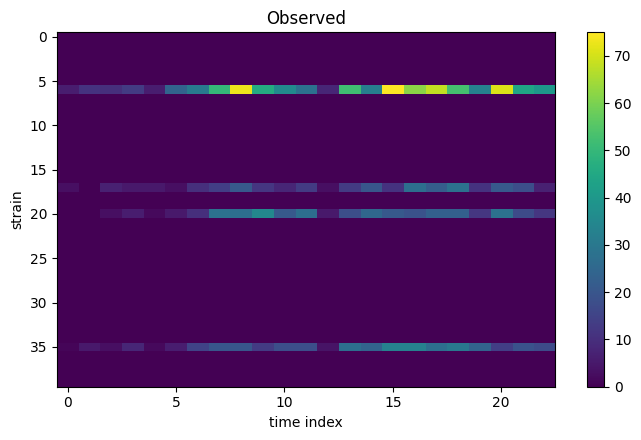

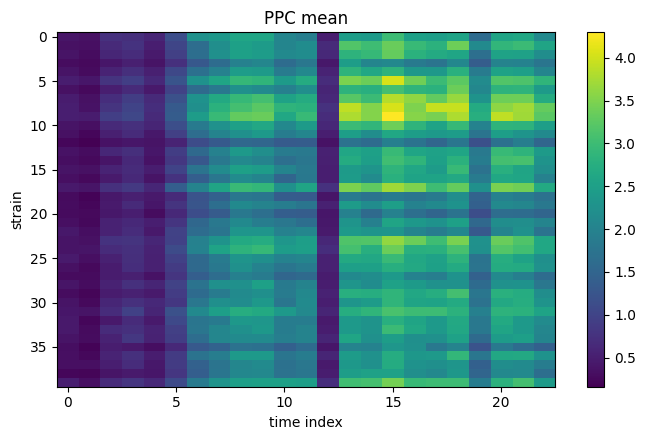

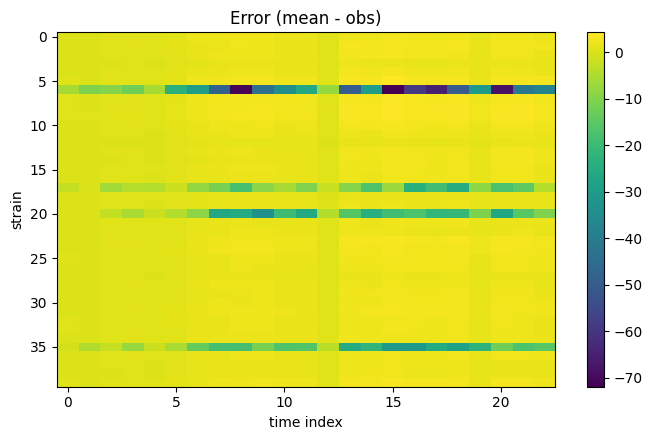

In [36]:
# heatmap
def heatmap(M, title):
    plt.figure(figsize=(7,4.5))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("strain")
    plt.tight_layout()
    plt.show()

heatmap(y_obs_array, "Observed")
heatmap(pred_mean, "PPC mean")
heatmap(pred_mean - y_obs_array, "Error (mean - obs)")

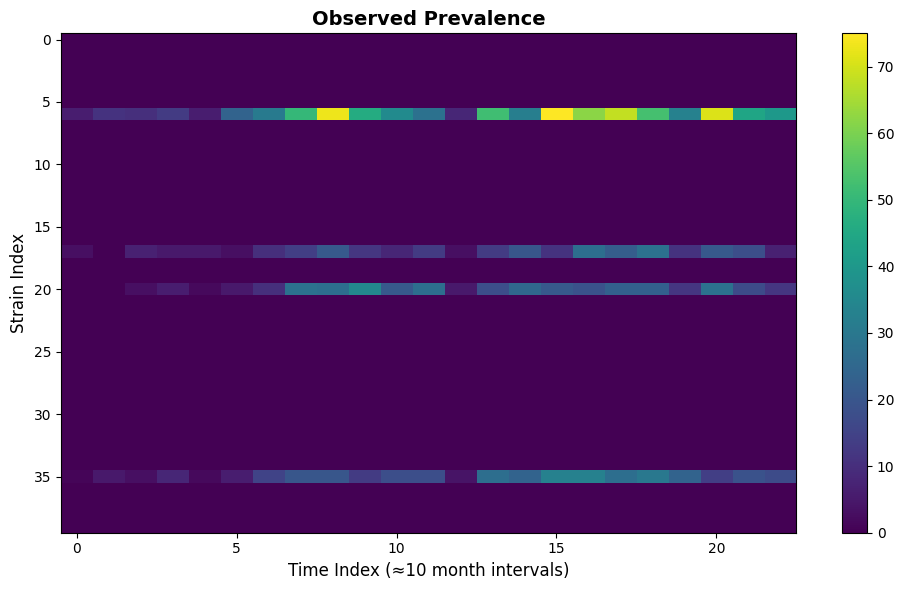

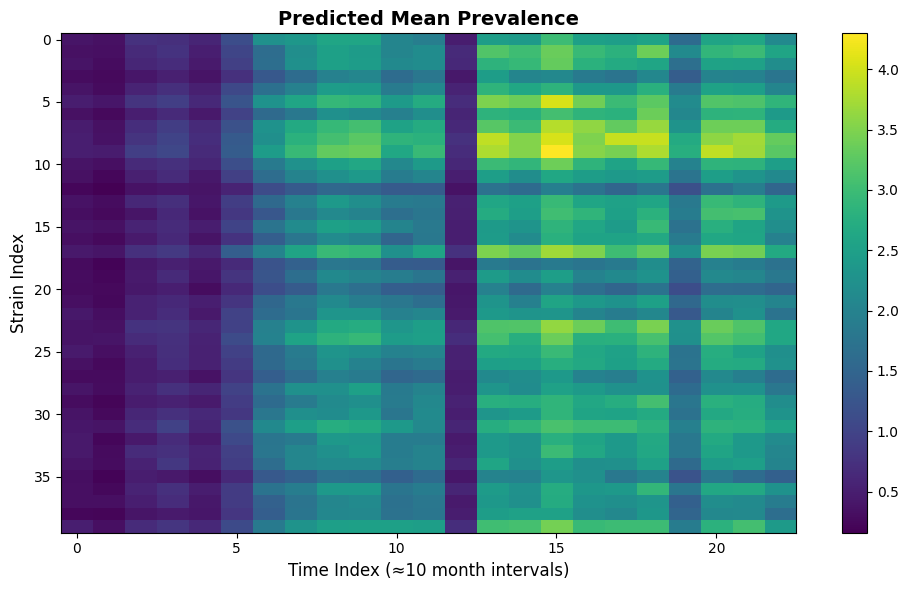

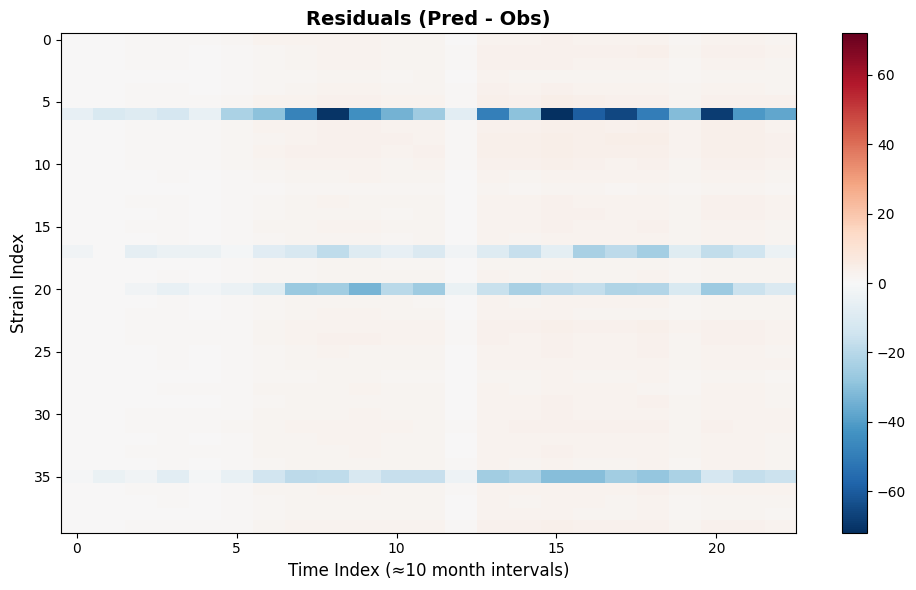

In [39]:
import matplotlib.pyplot as plt

def heatmap_enhanced(M, title, vmin=None, vmax=None, cmap='viridis', diverging=False):
    plt.figure(figsize=(10, 6))
    
    # For residuals, use diverging colormap centered at 0
    if diverging:
        vmax = np.abs(M).max()
        vmin = -vmax
        cmap = 'RdBu_r'  # Red=positive error, Blue=negative error
    
    im = plt.imshow(M, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im)
    
    # Add more informative labels
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Time Index (≈10 month intervals)", fontsize=12)
    plt.ylabel("Strain Index", fontsize=12)
    
    # Optional: Add grid for easier reading
    plt.grid(False)
    
    plt.tight_layout()
    plt.show()

# Usage
heatmap_enhanced(y_obs_array, "Observed Prevalence")
heatmap_enhanced(pred_mean, "Predicted Mean Prevalence")
heatmap_enhanced(pred_mean - y_obs_array, "Residuals (Pred - Obs)", diverging=True)

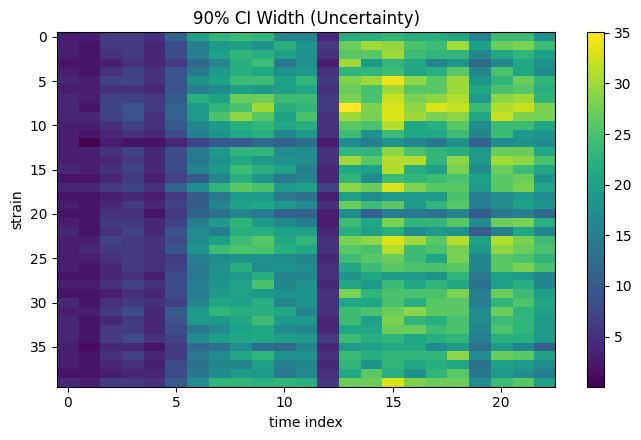

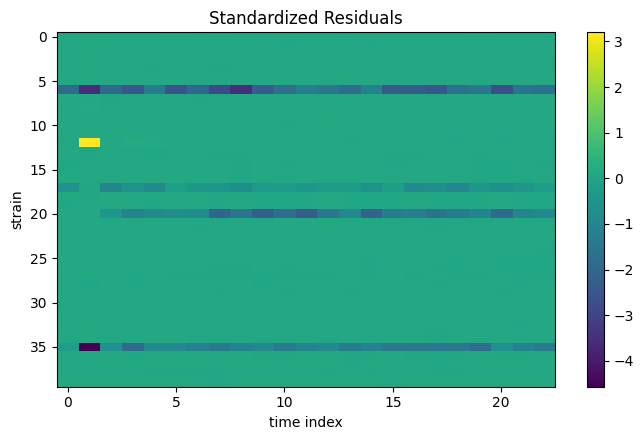

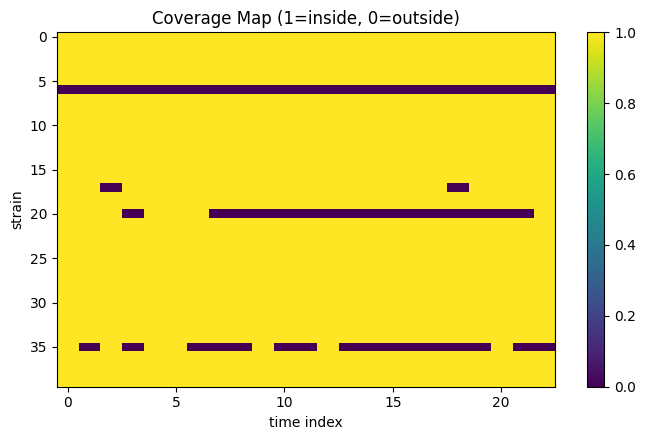

In [42]:
# 4. Uncertainty (width of credible intervals)
heatmap((pred_hi - pred_lo), "90% CI Width (Uncertainty)")
# Shows where model is most/least certain
# Wide intervals = high uncertainty, narrow = confident

# 5. Standardized residuals (accounts for uncertainty)
std_residuals = (pred_mean - y_obs_array) / (pred_hi - pred_lo)
heatmap(std_residuals, "Standardized Residuals")
# Values should be roughly in [-2, 2] range
# Outliers indicate poor fit even accounting for uncertainty

# 6. Coverage map (which cells are inside CI?)
heatmap(inside.astype(float), "Coverage Map (1=inside, 0=outside)")
# Shows spatial pattern of coverage
# Random = good, clustered = systematic problem


In [ ]:
import numpy as np
from numpy.random import default_rng, SeedSequence
from numpy.random import Generator as _NpGen, RandomState as _RS
import functions_list_260305 as functions_list
import summary_stats_elms_260305 as ss
import hashlib
import time
import matplotlib.pyplot as plt


start = time.perf_counter()

# ============================================================================
# SETUP: RNG and parameters
# ============================================================================
rng = np.random.default_rng(123)
core_params_num = 2  # core params: R0 and sigma

# fixed parameters
DurationSimulation = 20.0     # years: 20.0
Nstrains = 40       # number of strains: 42
omega = 0.2     # immunity cross strains: 0.1
x = 10.0        #
Cperweek = 34.53    #
Nagents = 1000      # number of agents
alpha = 0.007        # migration rate: 3.0
AgeDeath = 71.0     # life expectancy

# ============================================================================
# BUILD FIXED PARAMS ARRAY
# ============================================================================
if core_params_num == 2:
    Dimmunity = 10.0 * 52.14  # weeks: 0.5 * 52.14
    fixed_params = np.array([DurationSimulation, Nstrains, Dimmunity, omega,
                         x, Cperweek, Nagents, alpha,
                         AgeDeath], dtype=float)
elif core_params_num == 3:
    fixed_params = np.array([DurationSimulation, Nstrains, omega, x,
                             Cperweek, Nagents, alpha, AgeDeath], dtype=float)
else:
    raise ValueError('Invalid core params num')

# ============================================================================
# FUNCTION: build_params
# ============================================================================
def build_params(theta, fixed_params, core_params_num):
    theta = np.asarray(theta, float).ravel()
    if theta.size != core_params_num:
        raise ValueError(f"theta must be length-{core_params_num}, got {np.shape(theta)}")
    if core_params_num == 2:
        R0, sigma = float(theta[0]), float(theta[1])
        return np.array([fixed_params[0], fixed_params[1], fixed_params[2], sigma,
                         fixed_params[3], fixed_params[4], fixed_params[5], fixed_params[6],
                         fixed_params[7], fixed_params[8], R0
                         ], dtype=float)
    elif core_params_num == 3:
        R0, sigma, Dimmunity = float(theta[0]), float(theta[1]), float(theta[2])
        return np.array([fixed_params[0], fixed_params[1], Dimmunity, sigma,
                         fixed_params[2], fixed_params[3], fixed_params[4], fixed_params[5],
                         fixed_params[6], fixed_params[7], R0
                         ], dtype=float)
    else:
        raise ValueError('Invalid core params num')

# ============================================================================
# FUNCTION: seed_from_theta
# ============================================================================
def seed_from_theta(theta, master_seed: int = 123):
    th = np.asarray(theta, np.float64).ravel()
    b  = th.tobytes() + np.uint64(master_seed).tobytes()
    return int.from_bytes(hashlib.sha1(b).digest()[:8], 'little')

# ============================================================================
# FUNCTION: simulate_prevalence_v5_numba
# ============================================================================
def simulate_prevalence_v5_numba(theta, fixed_params, core_params_num, seed):
    seed = seed_from_theta(theta, master_seed=seed)
    rng = default_rng(seed)
    params = build_params(theta, fixed_params, core_params_num)
    AC, IMM, _ = functions_list.initialise_agents_v5(params, rng=rng)
    SSPrev_selected, SSPrev, AIBKS = functions_list.simulator_v5_numba(
        AC, IMM, params, 0, 1, seed=seed
    )
    return SSPrev_selected.astype(float)

# ============================================================================
# FUNCTION: summary_stats
# ============================================================================
def summary_stats(series_2d):
    y = np.asarray(series_2d, float).ravel()
    avg_prev_obs = ss.avg_prev_numpy(series_2d)
    var_prev_obs = np.sqrt(ss.var_prev_numpy(series_2d))
    avg_npmi_obs = ss.avg_npmi_numpy(series_2d)
    div_all_isolates_obs = ss.div_all_isolates_numpy(series_2d)
    return np.array(
        [avg_prev_obs, var_prev_obs, avg_npmi_obs, div_all_isolates_obs], float)

# ============================================================================
# GENERATE SYNTHETIC DATA
# ============================================================================
if core_params_num == 2:
    _Tdry = simulate_prevalence_v5_numba(np.array([5.0, 0.4], float), fixed_params, core_params_num, seed=int(123))
    T = _Tdry.size
    print("T's size", T)
    _Tdry1 = simulate_prevalence_v5_numba(np.array([5.0, 0.4], float), fixed_params, core_params_num, seed=int(123))
    print(np.allclose(_Tdry, _Tdry1), _Tdry.shape == _Tdry1.shape)
elif core_params_num == 3:
    _Tdry = simulate_prevalence_v5_numba(np.array([5.0, 0.4, 0.25 * 52.14], float), fixed_params, core_params_num, seed=int(123))
    T = _Tdry.size
    print("T's size", T)
    _Tdry1 = simulate_prevalence_v5_numba(np.array([5.0, 0.4, 0.25 * 52.14], float), fixed_params, core_params_num, seed=int(123))
    print(np.allclose(_Tdry, _Tdry1), _Tdry.shape == _Tdry1.shape)
else:
    raise ValueError('Invalid core params num')

y_obs_array = _Tdry

# ============================================================================
# LOAD POSTERIOR SAMPLES
# ============================================================================
csv_path_R0 = "../../experimental_data/from_260312/R0_samps_2params_R05p0.csv"
csv_path_sigma = "../../experimental_data/from_260312/sigma_samps_2params_R05p0.csv"
total_length = 2000
R0_samps = np.loadtxt(csv_path_R0, delimiter=",")
sigma_samps = np.loadtxt(csv_path_sigma, delimiter=",")
R0_samps = np.asarray(R0_samps, dtype=float).ravel()
sigma_samps = np.asarray(sigma_samps, dtype=float).ravel()
theta_samps = np.column_stack((R0_samps, sigma_samps))
theta_samps = theta_samps[np.isfinite(theta_samps).all(axis=1)]
theta_samps = theta_samps[:total_length]
R0_samps = theta_samps[:, 0]
sigma_samps = theta_samps[:, 1]
print("R0", R0_samps.shape, R0_samps[:10])
print("sigma", sigma_samps.shape, sigma_samps[:10])
print("theta", theta_samps.shape, theta_samps[:10, :])

# ============================================================================
# FUNCTION: simulate_at_obs
# ============================================================================
def simulate_at_obs(theta, seed):
    rng = np.random.default_rng(seed)
    Y = simulate_prevalence_v5_numba(theta, fixed_params, core_params_num, seed=seed)
    return Y

# ============================================================================
# GENERATE POSTERIOR PREDICTIVE CHECKS
# ============================================================================
ppc = []
for m, th in enumerate(theta_samps):
    Y_m = simulate_at_obs(th, seed=123)
    ppc.append(Y_m)
ppc = np.stack(ppc, axis=0)

# ============================================================================
# COMPUTE PREDICTIVE SUMMARIES
# ============================================================================
pred_mean = ppc.mean(axis=0) 
pred_lo, pred_hi = np.quantile(ppc, [0.05, 0.95], axis=0)

# ============================================================================
# FUNCTION: rmse
# ============================================================================
def rmse(A, B, mask=None):
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    if mask is None:
        mask = np.isfinite(A) & np.isfinite(B)
    d = A[mask] - B[mask]
    return float(np.sqrt(np.mean(d*d)))

# ============================================================================
# FUNCTION: mae
# ============================================================================
def mae(A, B, mask=None):
    A = np.asarray(A, float)
    B = np.asarray(B, float)
    if mask is None:
        mask = np.isfinite(A) & np.isfinite(B)
    return float(np.mean(np.abs(A[mask] - B[mask])))

# ============================================================================
# COMPUTE ERROR METRICS
# ============================================================================
rmse_mean = rmse(pred_mean, y_obs_array)
mae_mean  = mae(pred_mean, y_obs_array)
print("rmse:", rmse_mean)
print("mae:", mae_mean)

# ============================================================================
# COMPUTE COVERAGE
# ============================================================================
inside = (y_obs_array >= pred_lo) & (y_obs_array <= pred_hi)
coverage = float(np.mean(inside[np.isfinite(y_obs_array)]))
print("coverage:", coverage)

end = time.perf_counter()
print(f"Elapsed: {end - start:.4f} s")

# ============================================================================
# FUNCTION: heatmap
# ============================================================================
def heatmap(M, title, save_path=None):
    plt.figure(figsize=(7, 4.5))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.title(title)
    plt.xlabel("time index")
    plt.ylabel("strain")
    plt.tight_layout()
    plt.savefig(f"{save_path}{title}.png", dpi=300, bbox_inches="tight")
    plt.show()

# ============================================================================
# VISUALIZE RESULTS
# ============================================================================
heatmap(y_obs_array, "Observed", save_path="../../figures/from_260312/ppc/sigma0p4/R05p0/")
heatmap(pred_mean, "PPC mean", save_path="../../figures/from_260312/ppc/sigma0p4/R05p0/")
heatmap(pred_mean - y_obs_array, "Error (mean - obs)", save_path="../../figures/from_260312/ppc/sigma0p4/R05p0/")

# ============================================================================
# ADDITIONAL DIAGNOSTICS (OPTIONAL)
# ============================================================================
# Uncertainty heatmap
heatmap(pred_hi - pred_lo, "90% CI Width (Uncertainty)", save_path="../../figures/from_260312/ppc/sigma0p4/R05p0/")

# Coverage map
heatmap(inside.astype(float), "Coverage Map (1=inside, 0=outside)", save_path="../../figures/from_260312/ppc/sigma0p4/R05p0/")

# Strain-specific metrics
strain_coverage = inside.mean(axis=1)
strain_mae = np.abs(pred_mean - y_obs_array).mean(axis=1)
print("Worst strain coverage:", strain_coverage.min())
print("Best strain coverage:", strain_coverage.max())
print("Worst strain MAE:", strain_mae.max())

# Time-specific metrics
time_coverage = inside.mean(axis=0)
time_mae = np.abs(pred_mean - y_obs_array).mean(axis=0)
print("Worst time coverage:", time_coverage.min())
print("Best time coverage:", time_coverage.max())
print("Worst time MAE:", time_mae.max())

# ============================================================================
# SUMMARY REPORT
# ============================================================================
print("=" * 60)
print("POSTERIOR PREDICTIVE CHECK RESULTS")
print("=" * 60)
print(f"Ground truth:      R0 = 2.5, sigma = 0.4")
print(f"Posterior samples: {len(theta_samps)}")
print(f"R0 posterior:      {R0_samps.mean():.3f} ± {R0_samps.std():.3f}")
print(f"sigma posterior:   {sigma_samps.mean():.3f} ± {sigma_samps.std():.3f}")
print("-" * 60)
print(f"RMSE:              {rmse_mean:.6f}")
print(f"MAE:               {mae_mean:.6f}")
print(f"90% CI Coverage:   {coverage*100:.2f}%")
print(f"Expected Coverage: 90.00%")
print("-" * 60)
if 0.88 <= coverage <= 0.92:
    print("Status: ✓ Well-calibrated uncertainty")
elif coverage < 0.88:
    print("Status: ⚠ Under-coverage (model overconfident)")
else:
    print("Status: ⚠ Over-coverage (model underconfident)")
print("=" * 60)